In [130]:
import pandas as pd

train = pd.read_csv("dataset/CMaps/train_FD001.txt", sep=" ", header=None)
train = train.dropna(axis=1)

train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [131]:
train.columns = [
'engine_id','cycle',
'os1','os2','os3',
'sensor1','sensor2','sensor3','sensor4','sensor5',
'sensor6','sensor7','sensor8','sensor9','sensor10',
'sensor11','sensor12','sensor13','sensor14','sensor15',
'sensor16','sensor17','sensor18','sensor19','sensor20','sensor21'
]

In [132]:
max_cycles = train.groupby('engine_id')['cycle'].max()
max_cycles.head()

engine_id
1    192
2    287
3    179
4    189
5    269
Name: cycle, dtype: int64

In [133]:
train = train.merge(max_cycles, on='engine_id', suffixes=('', '_max'))

In [134]:
train['RUL'] = train['cycle_max'] - train['cycle']

What we just did is calculate Remaining useful life from current cycle and max no. of cycles for individual engines.

Now we only need features that are useful. Sensors that have constant values are not needed and can be removed to better and reduce the dataset.

In [135]:
train.nunique()[train.nunique() <= 1]

os3         1
sensor1     1
sensor5     1
sensor10    1
sensor16    1
sensor18    1
sensor19    1
dtype: int64

In [136]:
train = train.drop(columns=['sensor1','sensor5','sensor10','sensor16','sensor18','sensor19'])

so we dropped unneeded columns

In [137]:
from sklearn.preprocessing import MinMaxScaler

X = train.drop(columns=['engine_id','cycle_max','RUL'])  # keep cycle
y = train['RUL']
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [138]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [139]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [140]:
from sklearn.metrics import mean_absolute_error

y_pred_val = xgb_model.predict(X_val)

mae_val = mean_absolute_error(y_val, y_pred_val)

print("Validation MAE:", mae_val)

Validation MAE: 25.44476890563965


In [141]:
test = pd.read_csv("dataset/CMaps/test_FD001.txt", sep=" ", header=None)
test = test.dropna(axis=1)

In [142]:
test.columns = [
'engine_id','cycle',
'os1','os2','os3',
'sensor1','sensor2','sensor3','sensor4','sensor5',
'sensor6','sensor7','sensor8','sensor9','sensor10',
'sensor11','sensor12','sensor13','sensor14','sensor15',
'sensor16','sensor17','sensor18','sensor19','sensor20','sensor21'
]

In [143]:
test = test.drop(columns=['sensor1','sensor5','sensor10','sensor16','sensor18','sensor19'])

In [144]:
X_cols = X.columns
test_scaled = test.copy()
test_scaled[X_cols] = scaler.transform(test_scaled[X_cols])
test_last = test_scaled.groupby('engine_id').last().reset_index()
X_test_real = test_last[X_cols]


In [145]:
y_pred_real = xgb_model.predict(X_test_real)

In [146]:
rul_true = pd.read_csv("dataset/CMaps/RUL_FD001.txt", header=None)

In [147]:
from sklearn.metrics import mean_absolute_error

mae_real = mean_absolute_error(rul_true, y_pred_real)

print("Final Test MAE:", mae_real)

Final Test MAE: 19.902973175048828


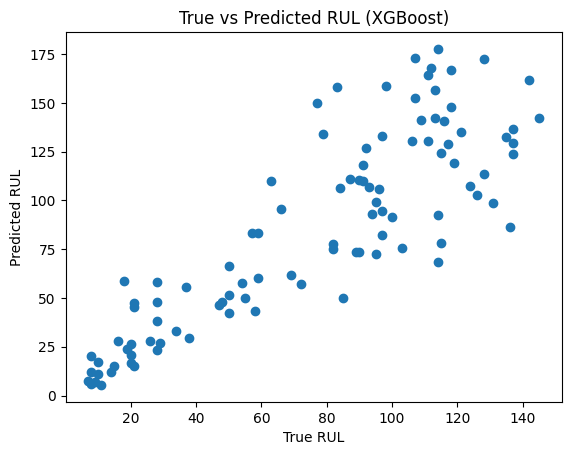

In [148]:
import matplotlib.pyplot as plt

plt.scatter(rul_true, y_pred_real)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("True vs Predicted RUL (XGBoost)")
plt.show()

In [149]:
from sklearn.metrics import mean_absolute_error

mae_real = mean_absolute_error(rul_true, y_pred_real)

print("XGBoost Test MAE:", mae_real)

XGBoost Test MAE: 19.902973175048828


PREDICTING ANOMALY

In [150]:
# Predict RUL for all rows in training data
train_pred_rul = xgb_model.predict(X_scaled)

# Add predicted RUL as a new column
train_anomaly = train.copy()
train_anomaly['predicted_RUL'] = train_pred_rul

train_anomaly.head()

,engine_id,cycle,os1,os2,os3,sensor2,sensor3,sensor4,sensor6,sensor7,...,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21,cycle_max,RUL,predicted_RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,21.61,554.36,...,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,192,191,228.828964
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,21.61,553.75,...,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,192,190,197.299240
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,21.61,554.26,...,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,192,189,200.313904
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,21.61,554.45,...,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,192,188,217.197800
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,21.61,554.00,...,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,192,187,212.359055


In [151]:
anomaly_features = list(X_cols) + ['predicted_RUL']

X_anomaly = train_anomaly[anomaly_features]

In [152]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_model.fit(X_anomaly)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [153]:
train_anomaly['anomaly'] = iso_model.predict(X_anomaly)

train_anomaly[['engine_id','cycle','predicted_RUL','anomaly']].head()

,engine_id,cycle,predicted_RUL,anomaly
0,1,1,228.828964,1
1,1,2,197.299240,1
2,1,3,200.313904,1
3,1,4,217.197800,1
4,1,5,212.359055,1


In [154]:
# Detect sensor faults using all available sensor columns
sensor_columns = [col for col in train_anomaly.columns if "sensor" in col]

for s in sensor_columns:
    
    mean = train_anomaly[s].mean()
    std = train_anomaly[s].std()

    train_anomaly[f"{s}_fault"] = abs(train_anomaly[s] - mean) > 3 * std


# Combine all sensor fault flags
fault_cols = [col for col in train_anomaly.columns if "_fault" in col]

train_anomaly["sensor_fault"] = train_anomaly[fault_cols].any(axis=1)

In [155]:
train_anomaly['anomaly'].value_counts()

anomaly
 1    19599
-1     1032
Name: count, dtype: int64

In [156]:
train_anomaly.groupby('anomaly')['predicted_RUL'].mean()

anomaly
-1     20.688200
 1    112.699936
Name: predicted_RUL, dtype: float32

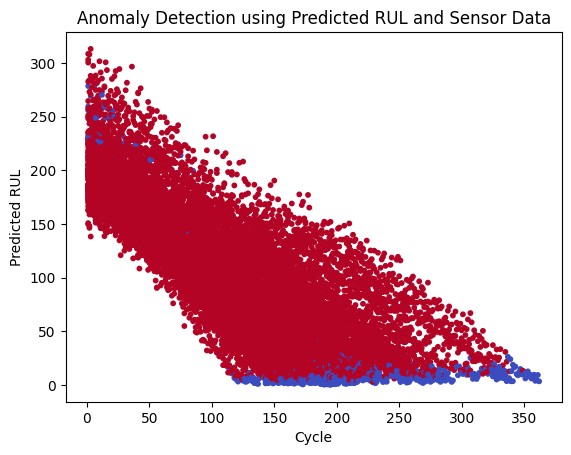

In [159]:
import matplotlib.pyplot as plt

plt.scatter(train_anomaly['cycle'], train_anomaly['predicted_RUL'],
            c=train_anomaly['anomaly'], cmap='coolwarm', s=10)

plt.xlabel("Cycle")
plt.ylabel("Predicted RUL")
plt.title("Anomaly Detection using Predicted RUL and Sensor Data")

plt.show()

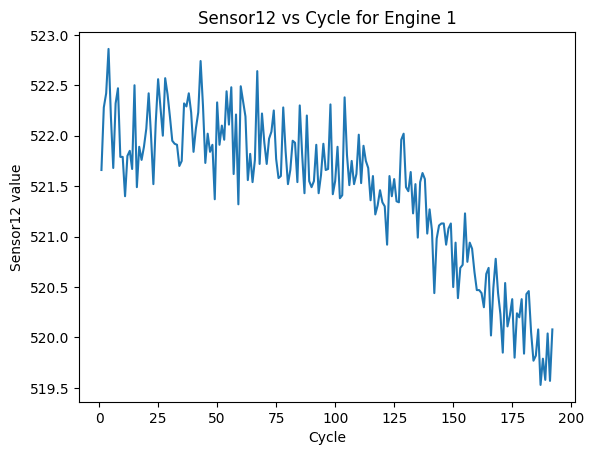

In [160]:
engine_id_example = 1

engine_data = train_anomaly[train_anomaly['engine_id'] == engine_id_example]
import matplotlib.pyplot as plt

plt.figure()

plt.plot(engine_data['cycle'], engine_data['sensor12'])

plt.xlabel("Cycle")
plt.ylabel("Sensor12 value")
plt.title(f"Sensor12 vs Cycle for Engine {engine_id_example}")

plt.show()

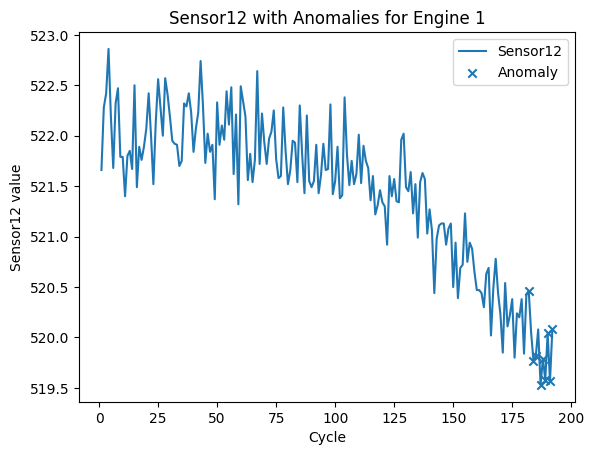

In [161]:
plt.figure()

plt.plot(engine_data['cycle'], engine_data['sensor12'], label="Sensor12")

anomaly_points = engine_data[engine_data['anomaly'] == -1]

plt.scatter(anomaly_points['cycle'],
            anomaly_points['sensor12'],
            label="Anomaly",
            marker='x')

plt.xlabel("Cycle")
plt.ylabel("Sensor12 value")
plt.title(f"Sensor12 with Anomalies for Engine {engine_id_example}")

plt.legend()

plt.show()

In [162]:
def maintenance_decision(row):

    if row['anomaly'] == -1 and row['predicted_RUL'] >= 20:
        return "WARNING - Abnormal Sensor Behaviour"

    elif row['predicted_RUL'] < 20:
        return "CRITICAL - Maintenance Required"

    else:
        return "Normal Operation"

In [163]:
train_anomaly['decision'] = train_anomaly.apply(maintenance_decision, axis=1)

In [164]:
train_anomaly['decision'] = train_anomaly.apply(maintenance_decision, axis=1)

In [165]:
train_anomaly['decision'].value_counts()

decision
Normal Operation                       18646
CRITICAL - Maintenance Required         1892
WARNING - Abnormal Sensor Behaviour       93
Name: count, dtype: int64

In [166]:
train_anomaly.to_csv("telemetry_results.csv", index=False)